# SEC Form 4: Insider Transaction Analysis

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`

## Purpose

This notebook demonstrates parsing and analyzing SEC Form 4 insider transaction
filings. Form 4 reports must be filed within 2 business days of an insider trade,
making them valuable for detecting informed trading activity.

## Learning Objectives

After completing this notebook, you will be able to:
- Parse Form 4 XML structure and extract transaction data
- Build insider transaction DataFrames from raw filings
- Identify patterns in insider buying and selling

## Prerequisites

This notebook requires Form 4 filings downloaded via:
```bash
uv run python data/equities/positioning/form4_download.py --ticker TSLA --count 20
```

## Cross-References

- **Download Script**: `data/equities/positioning/form4_download.py`
- **Related**: [`02_sec_filing_explorer`](02_sec_filing_explorer.ipynb) (edgartools for interactive exploration)
- **Downstream**: Insider sentiment signals for ML features

In [1]:
"""SEC Form 4: Insider Transaction Analysis — parse and analyze insider trading filings."""

import warnings

warnings.filterwarnings("ignore")

import re
from datetime import datetime
from pathlib import Path

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils import DATA_DIR
from utils.style import COLORS  # importing utils.style activates the ml4t Plotly template

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

# Form 4 data directory (populated by data/equities/positioning/form4_download.py)
FORM4_DIR = DATA_DIR / "equities" / "positioning" / "form4"

---
## Part 1: Check Data Availability

Form 4 filings are downloaded separately using the canonical script at
`data/equities/positioning/form4_download.py`.

In [3]:
# Check what's on disk. The download script (see Prerequisites above) populates one
# subdirectory per ticker; abort with a clear message if nothing is there.
if not FORM4_DIR.exists() or not any(FORM4_DIR.iterdir()):
    raise FileNotFoundError(
        f"No Form 4 filings under {FORM4_DIR}. "
        "Run: uv run python data/equities/positioning/form4_download.py --ticker TSLA --count 20"
    )

tickers = sorted(d.name for d in FORM4_DIR.iterdir() if d.is_dir())
if MAX_SYMBOLS > 0:  # CI/Papermill knob: cap the number of issuers processed
    tickers = tickers[:MAX_SYMBOLS]
for ticker in tickers:
    n = len(list((FORM4_DIR / ticker).rglob("*.xml")))
    print(f"  {ticker.upper()}: {n} filings")

  TSLA: 20 filings


In [4]:
# Enumerate every filing on disk (restricted to the selected issuers); sample the
# first three to inspect file sizes.
downloaded = sorted(f for t in tickers for f in (FORM4_DIR / t).rglob("*.xml"))
print(f"Total filings found: {len(downloaded)}")
for f in downloaded[:3]:
    print(f"  {f.relative_to(FORM4_DIR)} ({f.stat().st_size / 1024:.1f} KB)")

Total filings found: 20
  TSLA/000110465925066775.xml (24.7 KB)
  TSLA/000110465925068165.xml (7.0 KB)
  TSLA/000110465925073753.xml (4.5 KB)


---
## Part 2: Parsing Form 4 Transactions

Form 4 filings are XML documents. We parse them to extract structured data.

### Key XML Elements

| Element | Description |
|---------|-------------|
| `<issuerName>` | Company name |
| `<rptOwnerName>` | Insider name |
| `<officerTitle>` | Position (CEO, CFO, Director, etc.) |
| `<transactionCode>` | Trade type (P=Purchase, S=Sale, etc.) |
| `<transactionShares>` | Number of shares |
| `<transactionPricePerShare>` | Price per share |

In [5]:
def extract_value(text: str) -> str | None:
    """Extract value from XML <value> tag."""
    match = re.search(r"<value>(.+?)</value>", text)
    return match.group(1).strip() if match else None

### Parse a Complete Form 4 Filing
Extract header info (issuer, owner, title) and all non-derivative transactions.

In [6]:
def parse_form4(file_path: Path) -> dict:
    """Parse a Form 4 filing and return structured data."""
    content = file_path.read_text(errors="ignore")

    # Extract header info
    issuer = re.search(r"<issuerName>(.+?)</issuerName>", content)
    owner = re.search(r"<rptOwnerName>(.+?)</rptOwnerName>", content)
    title = re.search(r"<officerTitle>(.+?)</officerTitle>", content)

    header = {
        "issuer": issuer.group(1).strip() if issuer else "N/A",
        "owner": owner.group(1).strip() if owner else "N/A",
        "title": title.group(1).strip() if title else "N/A",
    }

    # Extract non-derivative transactions
    transactions = re.findall(
        r"<transactionCode>(.+?)</transactionCode>.*?"
        r"<transactionDate>(.+?)</transactionDate>.*?"
        r"<transactionShares>(.+?)</transactionShares>.*?"
        r"<transactionPricePerShare>(.+?)</transactionPricePerShare>",
        content,
        re.DOTALL,
    )

    tx_list = []
    for code, date_str, shares_str, price_str in transactions:
        date_value = extract_value(date_str)
        shares_value = extract_value(shares_str)
        price_value = extract_value(price_str)

        if all([code, date_value, shares_value]):
            try:
                tx_list.append(
                    {
                        "code": code.strip(),
                        "timestamp": datetime.strptime(date_value, "%Y-%m-%d").date(),
                        "shares": float(shares_value),
                        "price": float(price_value) if price_value and price_value != "D" else 0.0,
                    }
                )
            except (ValueError, TypeError):
                continue

    return {"header": header, "transactions": tx_list}

In [7]:
# Parse a single filing as a smoke test before processing the full set.
result = parse_form4(downloaded[0])
print(f"Issuer: {result['header']['issuer']}")
print(f"Owner:  {result['header']['owner']}")
print(f"Title:  {result['header']['title']}")
print(f"Transactions: {len(result['transactions'])}")
if result["transactions"]:
    print(f"First transaction: {result['transactions'][0]}")

Issuer: Tesla, Inc.
Owner:  Taneja Vaibhav
Title:  Chief Financial Officer
Transactions: 5
First transaction: {'code': 'M', 'timestamp': datetime.date(2025, 7, 7), 'shares': 193.0, 'price': 289.948}


### 2.1 Transaction Codes

| Code | Description |
|------|-------------|
| P | Open market purchase |
| S | Open market sale |
| A | Grant or award |
| M | Exercise of derivative (options) |
| X | Exercise of in-the-money options |
| G | Gift |
| D | Disposition to issuer |
| F | Payment of tax via shares |
| C | Conversion of derivative |
| I | Discretionary transaction |

In [8]:
# Transaction code mapping
CODE_MAP = {
    "P": "Purchase",
    "S": "Sale",
    "A": "Grant",
    "D": "Disposition",
    "M": "Exercise",
    "C": "Conversion",
    "F": "Tax payment",
    "I": "Discretionary",
    "X": "ITM Exercise",
    "G": "Gift",
}

---
## Part 3: Building a Transaction DataFrame

Process all downloaded filings into a structured DataFrame.

In [9]:
# Parse every filing into a flat list of transactions tagged with the issuer/owner/title.
# Real-world Form 4 XML occasionally contains malformed fields; we capture parse errors
# rather than abort the whole batch.
all_transactions = []
parse_errors = []
for file_path in downloaded:
    try:
        parsed = parse_form4(file_path)
        for tx in parsed["transactions"]:
            tx.update(parsed["header"])
            all_transactions.append(tx)
    except Exception as exc:
        parse_errors.append((file_path.name, str(exc)[:80]))

print(f"Transactions extracted: {len(all_transactions)} (parse errors: {len(parse_errors)})")

Transactions extracted: 46 (parse errors: 0)


In [10]:
# Promote raw codes to readable transaction types and inspect the panel.
df = pl.DataFrame(all_transactions).with_columns(
    pl.col("code").replace_strict(CODE_MAP, default="Unknown").alias("transaction_type")
)
df

code,timestamp,shares,price,issuer,owner,title,transaction_type
str,date,f64,f64,str,str,str,str
"""M""",2025-07-07,193.0,289.948,"""Tesla, Inc.""","""Taneja Vaibhav""","""Chief Financial Officer""","""Exercise"""
"""S""",2025-07-07,1100.0,291.999,"""Tesla, Inc.""","""Taneja Vaibhav""","""Chief Financial Officer""","""Sale"""
"""S""",2025-07-07,907.0,294.348,"""Tesla, Inc.""","""Taneja Vaibhav""","""Chief Financial Officer""","""Sale"""
"""S""",2025-07-08,2000.0,18.22,"""Tesla, Inc.""","""Taneja Vaibhav""","""Chief Financial Officer""","""Sale"""
"""S""",2025-07-07,4000.0,0.0,"""Tesla, Inc.""","""Taneja Vaibhav""","""Chief Financial Officer""","""Sale"""
…,…,…,…,…,…,…,…
"""S""",2026-03-30,1000.0,361.035,"""Tesla, Inc.""","""Wilson-Thompson Kathleen""","""N/A""","""Sale"""
"""S""",2026-03-30,4001.0,363.083,"""Tesla, Inc.""","""Wilson-Thompson Kathleen""","""N/A""","""Sale"""
"""S""",2026-03-30,560.0,364.888,"""Tesla, Inc.""","""Wilson-Thompson Kathleen""","""N/A""","""Sale"""


In [11]:
# Aggregate by transaction type, ordered by share volume so the dominant category leads.
summary = (
    df.group_by("transaction_type")
    .agg(
        pl.len().alias("count"),
        pl.col("shares").sum().alias("total_shares"),
    )
    .sort("total_shares", descending=True)
)

The two panels below tell different stories. By *filing count*, sales are the most common
insider event; by *share volume*, a smaller number of open-market purchases dominates —
the first sign that trade frequency and economic weight are not the same thing.

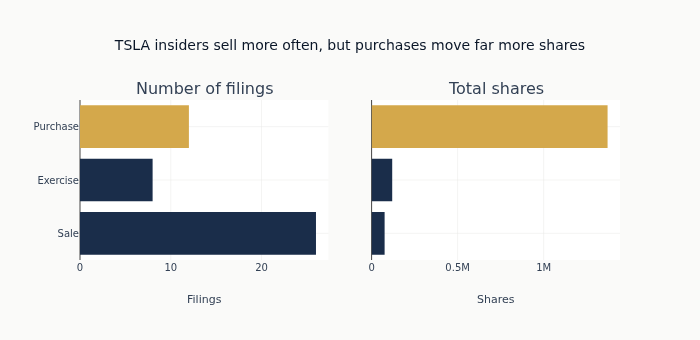

In [12]:
# Highlight the leading (largest-volume) category; keep the rest neutral.
types = summary["transaction_type"].to_list()
bar_colors = [COLORS["amber"] if i == 0 else COLORS["slate"] for i in range(len(types))]

fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    subplot_titles=("Number of filings", "Total shares"),
    horizontal_spacing=0.08,
)
fig.add_trace(
    go.Bar(y=types, x=summary["count"], orientation="h", marker_color=bar_colors),
    row=1,
    col=1,
)
fig.add_trace(
    go.Bar(y=types, x=summary["total_shares"], orientation="h", marker_color=bar_colors),
    row=1,
    col=2,
)
fig.update_yaxes(autorange="reversed")
fig.update_xaxes(title_text="Filings", row=1, col=1)
fig.update_xaxes(title_text="Shares", row=1, col=2)
fig.update_layout(
    title="TSLA insiders sell more often, but purchases move far more shares",
    showlegend=False,
    height=340,
)
fig.show()

---
## Part 4: Insider Activity Patterns

We now aggregate open-market purchases (P) and sales (S) by individual insider to see who
is transacting and in what dollar amount.

Form 4 occasionally reports a sale with `price = 0.0` as a placeholder (for example, a
planned disposition whose executed price is filed separately). Summing those rows into a
dollar total would conflate priced trades with unreported ones, so we keep them apart:
`total_value` is computed only on rows with a positive price, while `placeholder_trades`
and `placeholder_shares` track the share volume reported without a price.

In [13]:
market_trades = df.filter(pl.col("code").is_in(["P", "S"]))
priced = pl.col("price") > 0
by_owner = (
    market_trades.group_by(["owner", "transaction_type"])
    .agg(
        pl.len().alias("trades"),
        pl.col("shares").sum().alias("total_shares"),
        pl.when(priced)
        .then(pl.col("shares") * pl.col("price"))
        .otherwise(0.0)
        .sum()
        .alias("total_value"),
        (~priced).sum().alias("placeholder_trades"),
        pl.when(~priced).then(pl.col("shares")).otherwise(0.0).sum().alias("placeholder_shares"),
    )
    .sort("total_value", descending=True)
)
by_owner

owner,transaction_type,trades,total_shares,total_value,placeholder_trades,placeholder_shares
str,str,u32,f64,f64,u32,f64
"""Musk Elon""","""Purchase""",12,1.371671e6,5.3429e8,0,0.0
"""MURDOCH JAMES R""","""Sale""",11,30944.0,1.3821e7,0,0.0
"""Wilson-Thompson Kathleen""","""Sale""",10,21410.0,8.3229e6,0,0.0
"""Taneja Vaibhav""","""Sale""",4,8007.0,624612.536,1,4000.0
"""Musk Kimbal""","""Sale""",1,15242.0,0.0,1,15242.0


Charting the priced dollar value per insider makes the asymmetry unmistakable: a single
buyer accounts for essentially all of the open-market purchase value, while the sellers -
even added together - transact an order of magnitude less. Bars are colored by direction;
Kimbal Musk's lone reported sale carried no filed price, so it registers as a placeholder
with zero priced value.

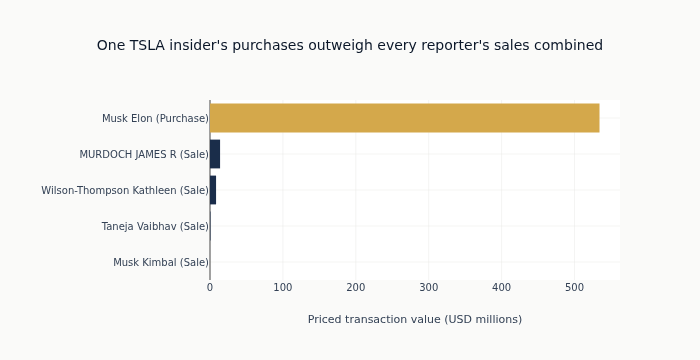

In [14]:
# One horizontal bar per insider, ordered by priced dollar value, colored by direction.
labels = [f"{o} ({t})" for o, t in zip(by_owner["owner"], by_owner["transaction_type"])]
value_colors = [
    COLORS["amber"] if t == "Purchase" else COLORS["slate"] for t in by_owner["transaction_type"]
]

fig = go.Figure(
    go.Bar(
        y=labels,
        x=by_owner["total_value"] / 1e6,
        orientation="h",
        marker_color=value_colors,
    )
)
fig.update_yaxes(autorange="reversed")
fig.update_layout(
    title="One TSLA insider's purchases outweigh every reporter's sales combined",
    xaxis_title="Priced transaction value (USD millions)",
    height=360,
    margin=dict(l=210),
)
fig.show()

---
## Key Takeaways

1. Form 4 filings are XML documents with a small, stable schema (`issuerName`, `rptOwnerName`, `officerTitle`, and one or more transaction blocks). A handful of regular expressions extract them into a flat panel.
2. The transaction-code dictionary is the load-bearing piece: open-market purchases (P) and sales (S) are the only signals tied directly to insider conviction; option exercises (M/X), grants (A), tax payments (F), and gifts (G) are noise unless explicitly modelled.
3. Aggregating by insider × transaction type surfaces the dollar-weighted activity pattern — in the TSLA sample, Elon Musk's 12 purchases dwarf the cumulative selling activity of every other reporter.
4. **For ML features**: net insider buying/selling ratio, purchase-to-sale dollar ratio, and cluster detection (multiple insiders transacting together) are the natural primitives built on top of this DataFrame.
5. For interactive single-company workflows, prefer EdgarTools ([`02_sec_filing_explorer`](02_sec_filing_explorer.ipynb)); use the bulk download path here when scaling to many issuers.